In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [ ]:
# Set parameters for the signal
N = 2048                # Number of sample points
T = 1.0                  # Duration of the signal in seconds
f0 = 1                   # fundamental frequency of the square wave in Hz

# list of harmonic numbers when constructing square wave
harmonics = [1, 3, 5, 20, 50] # this is the trial to test out 20 or 50 per the task description

So what we have in here for harmonics is basically how many counts of odd harmonics, and why odd harmonics is because the formula for the Fourier series is an odd number (n = 2k+1). There can only be maximum 6 elements in the harmonics because the plot is size 2 by 3 written below.

In [25]:
# Reconstruct a square function (square wave) by summing sine waves of different frequencies using Fourier series.

# Define square wave function
def square_wave(t):
    return np.sign(np.sin(2.0 * np.pi * f0 * t))

# Fourier series approximation of square wave
def square_wave_fourier(t, f0, N):
    result = np.zeros_like(t)
    for k in range(N):
        n = 2 * k + 1  # Fourier series of a square wave only contains odd harmonics
        result += np.sin(2 * np.pi * n * f0 * t) / n # add harmonics to reconstruct square function
    return (4 / np.pi) * result

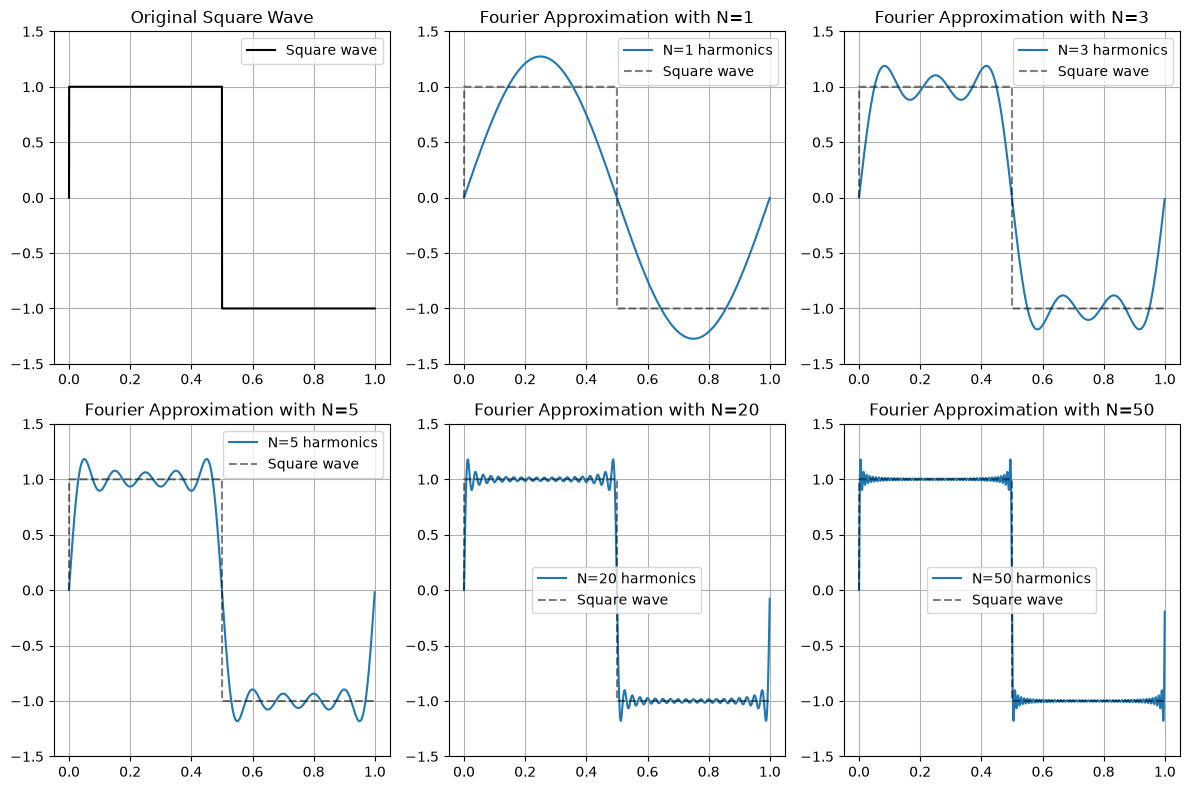

In [26]:
# Create the time vector
# np.linspace generates evenly spaced numbers over a specified interval.
# We use endpoint=False because the interval is periodic.
t = np.linspace(0.0, T, N, endpoint=False)

# generate original square wave
square = square_wave(t)

plt.figure(figsize=(12, 8))
# Plot original square wave
plt.subplot(2, 3, 1)
plt.plot(t, square, 'k', label="Square wave")
plt.title("Original Square Wave")
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.legend()
# Plot Fourier reconstructions
for i, Nh in enumerate(harmonics, start=2):
    plt.subplot(2, 3, i)
    y = square_wave_fourier(t, f0, Nh)
    plt.plot(t, y, label=f"N={Nh} harmonics")
    plt.plot(t, square, 'k--', alpha=0.5, label="Square wave")
    plt.title(f"Fourier Approximation with N={Nh}")
    plt.ylim(-1.5, 1.5)
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

- for n = [1,3,5], shape is far from the square wave
- shape gets closer to the square wave when we increse the number of harmonics summed (to a higher-order harmonic like 20 or 50)
- top and bottom regions get progressively flattened, transition becomes steeper
- n = 20 means first 20 odd harmonic
- each added harmonic is a smaller correction (amplitude of each harmonic scales as 1/n -> when we derive Fourier coefficients, we integrate sine term and get 1/n)
- even at n = 50, there is a spike near the jump that only narrows, doesn't shrink because a finite sum of smooth sine waves cannot exactly reproduce a sharp discontinuity